# 17. Spectrum Prediction via TS3Net-Style Triple Decomposition

Implements the **triple decomposition + temporal-frequency** idea from the paper:
**"TS3Net: Triple Decomposition with Spectrum Gradient for Long-Term Time Series Analysis"** (IEEE ICDE 2024).

## Paper (adapted to our setting)
- **Triple decomposition:** (1) Trend = moving average; Seasonal = X − Trend. (2) Spectrum expansion: seasonal → 2D temporal-frequency (TF). (3) Spectrum gradient → split seasonal into **regular-part** (stable periodicity) and **fluctuant-part** (dynamic spectrum). We approximate: Regular = low-pass of seasonal, Fluctuant = seasonal − Regular.
- **Prediction:** Process trend, regular, and fluctuant separately; each has a prediction head; final **Y = Y_trend + Y_regular + Y_fluctuant**.
- **TF-style block:** Expand 1D series to 2D (frequency × time) via FFT over windows; 2D Conv backbone; flatten → Dense(24). Used for regular and fluctuant.

## Same setup as 10–16
Data: work_dir/final, 72h→24h. Metrics: MAE, RMSE, MASE. Models: TS3Net-style, Naive. Same visuals.


**GPU:** Use kernel **Python 3.11 (cablelabs-3 .venv)** (Kernel → Change kernel) so TensorFlow uses the project's venv with tensorflow-metal.

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
print(f'TensorFlow: {tf.__version__}')


TensorFlow: 2.18.1


In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_visible_devices(gpus, 'GPU')
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'GPU enabled: {len(gpus)} device(s)')
        with tf.device('/GPU:0'):
            _ = tf.constant(1)
        print('GPU ready.')
    except RuntimeError as e: print('GPU config:', e)
else: print('No GPU found. Change kernel to "Python 3.11 (cablelabs-3 .venv)" (Kernel → Change kernel), then re-run from the top.')
USE_GPU = len(gpus) > 0


GPU enabled: 1 device(s)
GPU ready.


2026-02-09 23:45:00.823595: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-02-09 23:45:00.823624: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-02-09 23:45:00.823632: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1770698700.823646 42509532 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1770698700.823666 42509532 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## Data loading (same as notebook 10)

In [3]:
work_dir = Path("work_dir")
if not work_dir.exists():
    work_dir = Path("../work_dir")
final_dir = work_dir / "final"
training_dir = final_dir / "training"
testing_dir = final_dir / "testing"
if not final_dir.exists() or not training_dir.exists() or not testing_dir.exists():
    raise FileNotFoundError("work_dir/final/training and testing not found")
class_options = sorted([d.name for d in training_dir.iterdir() if d.is_dir()])
LOOKBACK = 72
FORECAST_HORIZON = 24
print(f"Bands: {class_options}, Lookback={LOOKBACK}, Horizon={FORECAST_HORIZON}")

def load_data_for_band(band_name: str, split: str):
    split_dir = final_dir / split / band_name
    if not split_dir.exists():
        return pd.DataFrame()
    dfs = []
    for p in sorted(split_dir.glob("final_*.parquet")):
        try:
            dfs.append(pd.read_parquet(p))
        except Exception as e:
            print(f"Error loading {p}: {e}")
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

def prepare_next_day_sequences(train_df, test_df, lookback=72, forecast_horizon=24):
    freqs = sorted(train_df["freq_center_ghz"].unique())
    ths = sorted(train_df["threshold_dbm"].unique())
    if len(ths) > 1:
        train_df = train_df[train_df["threshold_dbm"] == ths[0]].copy()
        test_df = test_df[test_df["threshold_dbm"] == ths[0]].copy()
    X_tr, y_tr, X_te, y_te = [], [], [], []
    for freq in freqs:
        tr = train_df[train_df["freq_center_ghz"] == freq].sort_values(["date", "hour"])["au_pct"].values
        te = test_df[test_df["freq_center_ghz"] == freq].sort_values(["date", "hour"])["au_pct"].values
        for i in range(len(tr) - lookback - forecast_horizon + 1):
            X_tr.append(tr[i:i+lookback])
            y_tr.append(tr[i+lookback:i+lookback+forecast_horizon])
        n_test_days = len(te) // forecast_horizon
        for d in range(n_test_days):
            if d == 0:
                inp = tr[-lookback:] if len(tr) >= lookback else np.concatenate([np.zeros(lookback - len(tr)), tr])
            else:
                h = max(0, lookback - d * forecast_horizon)
                inp = np.concatenate([tr[-h:], te[0:d*forecast_horizon]]) if h > 0 else te[d*forecast_horizon - lookback:d*forecast_horizon]
            tgt = te[d*forecast_horizon:(d+1)*forecast_horizon]
            if len(inp) == lookback and len(tgt) == forecast_horizon:
                X_te.append(inp)
                y_te.append(tgt)
    if not X_tr or not X_te:
        return np.array([]), np.array([]), np.array([]), np.array([])
    return np.array(X_tr).reshape(-1, lookback, 1), np.array(y_tr), np.array(X_te).reshape(-1, lookback, 1), np.array(y_te)

Bands: ['195MHz', '2441MHz', '3765MHz', '539MHz', '5500MHz', '915MHz'], Lookback=72, Horizon=24


In [4]:
train_data_by_band = {}
test_data_by_band = {}
for band in class_options:
    tr = load_data_for_band(band, "training")
    te = load_data_for_band(band, "testing")
    if not tr.empty and not te.empty:
        train_data_by_band[band] = tr
        test_data_by_band[band] = te
X_train_list, y_train_list, X_test_list, y_test_list = [], [], [], []
for band in class_options:
    if band not in train_data_by_band:
        continue
    X_tr, y_tr, X_te, y_te = prepare_next_day_sequences(train_data_by_band[band], test_data_by_band[band], LOOKBACK, FORECAST_HORIZON)
    if len(X_tr) > 0 and len(X_te) > 0:
        X_train_list.append(X_tr)
        y_train_list.append(y_tr)
        X_test_list.append(X_te)
        y_test_list.append(y_te)
X_train = np.vstack(X_train_list)
y_train = np.vstack(y_train_list)
X_test = np.vstack(X_test_list)
y_test = np.vstack(y_test_list)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (30821, 72, 1), Test: (1887, 72, 1)


## Triple decomposition (Trend, Regular, Fluctuant)
Trend = moving average; Seasonal = X − Trend; Regular = low-pass of seasonal; Fluctuant = Seasonal − Regular.

In [5]:
TREND_KERNEL = 12
REGULAR_KERNEL = 8
LAMBDA_TF = 16

def moving_avg_pad(x, kernel_size):
    """1D moving average with same padding. x: (T,) or (B,T,1)."""
    if x.ndim == 1:
        x = x.reshape(1, -1, 1)
    B, T, C = x.shape
    pad = kernel_size // 2
    x_pad = np.pad(x, ((0, 0), (pad, pad), (0, 0)), mode='edge')
    out = np.zeros_like(x)
    for i in range(T):
        out[:, i, :] = x_pad[:, i:i+kernel_size, :].mean(axis=1)
    return out

def triple_decompose(X):
    """X: (B, T, 1). Returns trend (B,T,1), regular (B,T,1), fluctuant (B,T,1)."""
    trend = moving_avg_pad(X, TREND_KERNEL)
    if trend.ndim == 2:
        trend = trend[:, :, np.newaxis]
    seasonal = X - trend
    regular = moving_avg_pad(seasonal, REGULAR_KERNEL)
    if regular.ndim == 2:
        regular = regular[:, :, np.newaxis]
    fluctuant = seasonal - regular
    return trend, regular, fluctuant

X_trend_tr, X_reg_tr, X_flu_tr = triple_decompose(X_train)
X_trend_te, X_reg_te, X_flu_te = triple_decompose(X_test)
print('Triple decomposition done. Shapes:', X_trend_tr.shape, X_reg_tr.shape, X_flu_tr.shape)

Triple decomposition done. Shapes: (30821, 72, 1) (30821, 72, 1) (30821, 72, 1)


## FFT-based 2D TF representation and TF-style block
Expand 1D (T,) to 2D (λ, T) by FFT magnitude over sliding windows; then 2D Conv → Flatten → Dense(24).

In [6]:
def build_tf_2d(series_1d, n_freq=LAMBDA_TF, win_len=24):
    """series_1d: (T,). Build 2D (n_freq, T) from FFT magnitudes over sliding windows."""
    T = series_1d.shape[-1]
    if T < win_len:
        win_len = max(4, T)
    series_1d = np.asarray(series_1d).ravel()
    pad = win_len // 2
    padded = np.pad(series_1d, (pad, pad), mode='edge')
    tf_2d = np.zeros((n_freq, T), dtype=np.float32)
    for t in range(T):
        w = padded[t:t + win_len]
        fft_mag = np.abs(np.fft.rfft(w))
        n_bins = len(fft_mag)
        for fi in range(min(n_freq, n_bins)):
            tf_2d[fi, t] = fft_mag[fi]
    return tf_2d

def build_tf_dataset(X_comp, n_freq=LAMBDA_TF):
    """X_comp: (B, T, 1). Output (B, n_freq, T, 1) for 2D Conv."""
    B, T, _ = X_comp.shape
    out = np.zeros((B, n_freq, T, 1), dtype=np.float32)
    for i in range(B):
        out[i, :, :, 0] = build_tf_2d(X_comp[i, :, 0], n_freq=n_freq)
    return out

def build_tf_block_model(n_freq, T, horizon, name='tf_block'):
    inp = layers.Input(shape=(n_freq, T, 1))
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inp)
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(horizon, activation='linear')(x)
    return keras.Model(inp, out, name=name)

tf_reg_model = build_tf_block_model(LAMBDA_TF, LOOKBACK, FORECAST_HORIZON, 'tf_regular')
tf_flu_model = build_tf_block_model(LAMBDA_TF, LOOKBACK, FORECAST_HORIZON, 'tf_fluctuant')
print('TF-block models built.')

TF-block models built.


In [7]:
scaler_trend = MinMaxScaler(feature_range=(0, 1))
scaler_reg = MinMaxScaler(feature_range=(0, 1))
scaler_flu = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_trend_tr_flat = X_trend_tr.reshape(-1, 1)
X_reg_tr_flat = X_reg_tr.reshape(-1, 1)
X_flu_tr_flat = X_flu_tr.reshape(-1, 1)
y_train_flat = y_train.reshape(-1, 1)
scaler_trend.fit(X_trend_tr_flat)
scaler_reg.fit(X_reg_tr_flat)
scaler_flu.fit(X_flu_tr_flat)
scaler_y.fit(y_train_flat)

X_trend_tr_s = scaler_trend.transform(X_trend_tr_flat).reshape(X_trend_tr.shape)
X_reg_tr_s = scaler_reg.transform(X_reg_tr_flat).reshape(X_reg_tr.shape)
X_flu_tr_s = scaler_flu.transform(X_flu_tr_flat).reshape(X_flu_tr.shape)
y_train_s = scaler_y.transform(y_train_flat).reshape(y_train.shape)

TF_reg_tr = build_tf_dataset(X_reg_tr_s, LAMBDA_TF)
TF_flu_tr = build_tf_dataset(X_flu_tr_s, LAMBDA_TF)
print('Train TF tensors:', TF_reg_tr.shape, TF_flu_tr.shape)

BATCH = 128 if USE_GPU else 32
EPOCHS = 40

trend_inp = layers.Input(shape=(LOOKBACK, 1))
trend_out = layers.GlobalAveragePooling1D()(trend_inp)
trend_out = layers.Dense(32, activation='relu')(trend_out)
trend_out = layers.Dense(FORECAST_HORIZON, activation='linear')(trend_out)
trend_model = keras.Model(trend_inp, trend_out, name='trend_head')

trend_model.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse', metrics=['mae'])
tf_reg_model.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse', metrics=['mae'])
tf_flu_model.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse', metrics=['mae'])

trend_model.fit(X_trend_tr_s, y_train_s / 3.0, epochs=EPOCHS, batch_size=BATCH, validation_split=0.2, verbose=1)
tf_reg_model.fit(TF_reg_tr, y_train_s / 3.0, epochs=EPOCHS, batch_size=BATCH, validation_split=0.2, verbose=1)
tf_flu_model.fit(TF_flu_tr, y_train_s / 3.0, epochs=EPOCHS, batch_size=BATCH, validation_split=0.2, verbose=1)
print('All three heads trained (Y = Y_trend + Y_regular + Y_fluctuant).')

Train TF tensors: (30821, 16, 72, 1) (30821, 16, 72, 1)
Epoch 1/40


2026-02-09 23:45:25.060211: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


193/193 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0049 - mae: 0.0349 - val_loss: 8.9281e-04 - val_mae: 0.0173
Epoch 2/40
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.3350e-04 - mae: 0.0162 - val_loss: 8.8835e-04 - val_mae: 0.0169
Epoch 3/40
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.1500e-04 - mae: 0.0154 - val_loss: 8.8895e-04 - val_mae: 0.0170
Epoch 4/40
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 9.1585e-04 - mae: 0.0154 - val_loss: 8.9882e-04 - val_mae: 0.0172
Epoch 5/40
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 9.1635e-04 - mae: 0.0155 - val_loss: 9.0120e-04 - val_mae: 0.0173
Epoch 6/40
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 9.1591e-04 - mae: 0.0155 - val_loss: 8.8407e-04 - val_mae: 0.0170
Epoch 7/40
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 9.1562e-04 - mae: 0.0154 - val_loss: 9.2855e-04 - val_mae: 0.0181
Epoch 8/40
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 9.1698e-04 - mae: 0.0155 - val_loss: 9.1346e-04 - val_mae: 0.0177
Epoc

In [8]:
X_trend_te_s = scaler_trend.transform(X_trend_te.reshape(-1, 1)).reshape(X_trend_te.shape)
X_reg_te_s = scaler_reg.transform(X_reg_te.reshape(-1, 1)).reshape(X_reg_te.shape)
X_flu_te_s = scaler_flu.transform(X_flu_te.reshape(-1, 1)).reshape(X_flu_te.shape)
TF_reg_te = build_tf_dataset(X_reg_te_s, LAMBDA_TF)
TF_flu_te = build_tf_dataset(X_flu_te_s, LAMBDA_TF)

y_trend_s = trend_model.predict(X_trend_te_s, verbose=0)
y_reg_s = tf_reg_model.predict(TF_reg_te, verbose=0)
y_flu_s = tf_flu_model.predict(TF_flu_te, verbose=0)
y_ts3net_s = y_trend_s + y_reg_s + y_flu_s
y_pred_ts3net = scaler_y.inverse_transform(y_ts3net_s.reshape(-1, 1)).reshape(y_test.shape)
y_pred_ts3net = np.clip(y_pred_ts3net, 0, 100).astype(np.float32)
print('TS3Net-style predictions done.')

TS3Net-style predictions done.


In [9]:
def naive_predictor(X, horizon):
    last = X[:, -1, 0]
    return np.tile(last.reshape(-1, 1), (1, horizon))
y_pred_naive = naive_predictor(X_test, FORECAST_HORIZON)

def calculate_mae(y_true, y_pred):
    return mean_absolute_error(y_true.flatten(), y_pred.flatten())
def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
def calculate_mase(y_true, y_pred, y_train):
    mae = np.mean(np.abs(y_true.flatten() - y_pred.flatten()))
    scale = np.mean(np.abs(np.diff(y_train.flatten()))) if len(y_train.flatten()) > 1 else 1.0
    return mae / max(scale, 1e-8)

mae_ts3 = calculate_mae(y_test, y_pred_ts3net)
rmse_ts3 = calculate_rmse(y_test, y_pred_ts3net)
mase_ts3 = calculate_mase(y_test, y_pred_ts3net, y_train)
mae_n = calculate_mae(y_test, y_pred_naive)
rmse_n = calculate_rmse(y_test, y_pred_naive)
mase_n = calculate_mase(y_test, y_pred_naive, y_train)

results_df = pd.DataFrame([
    {"Model": "TS3Net (triple decomp)", "MAE": mae_ts3, "RMSE": rmse_ts3, "MASE": mase_ts3},
    {"Model": "Naive Baseline", "MAE": mae_n, "RMSE": rmse_n, "MASE": mase_n},
])
results_df["MAE"] = results_df["MAE"].round(4)
results_df["RMSE"] = results_df["RMSE"].round(4)
results_df["MASE"] = results_df["MASE"].round(4)

print("\n" + "="*80)
print("FINAL RESULTS SUMMARY (same format as notebook 10)")
print("="*80)
print(f"Lookback: {LOOKBACK}h, Forecast: {FORECAST_HORIZON}h")
print(f"Test samples: {len(y_test)}")
print(f"\n{results_df.to_string(index=False)}")
display(results_df)


FINAL RESULTS SUMMARY (same format as notebook 10)
Lookback: 72h, Forecast: 24h
Test samples: 1887

                 Model     MAE    RMSE   MASE
TS3Net (triple decomp) 14.7054 22.4590 7.0535
        Naive Baseline  4.4497 10.2349 2.1343


,Model,MAE,RMSE,MASE
0,TS3Net (triple decomp),14.7054,22.4590,7.0535
1,Naive Baseline,4.4497,10.2349,2.1343


## Analysis and Visualizations (same as notebook 10)

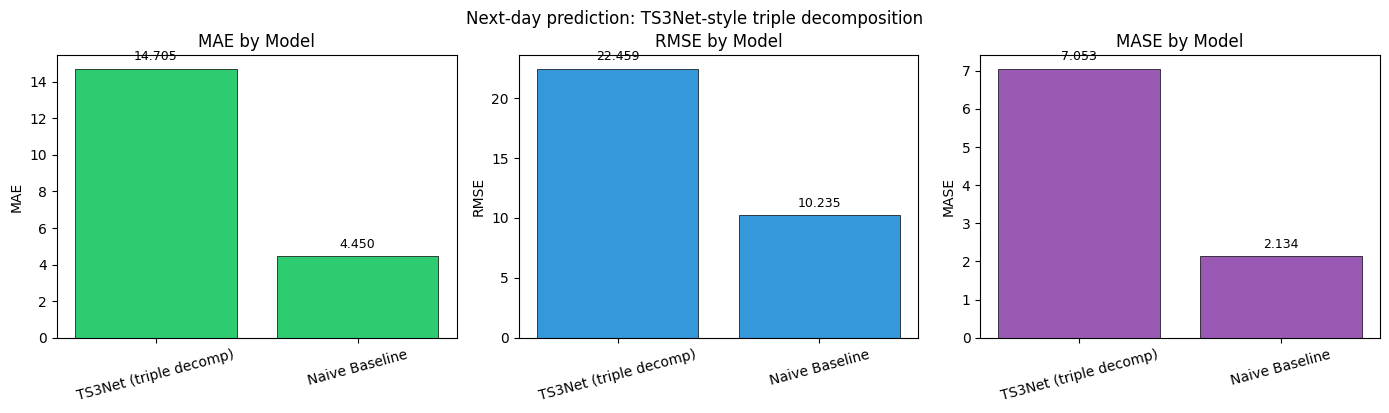

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['MAE', 'RMSE', 'MASE']
colors = ['#2ecc71', '#3498db', '#9b59b6']
for ax, metric, color in zip(axes, metrics, colors):
    vals = results_df[metric].values
    bars = ax.bar(results_df['Model'], vals, color=color, edgecolor='black', linewidth=0.5)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Model')
    ax.tick_params(axis='x', rotation=15)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02 * max(vals), f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.suptitle('Next-day prediction: TS3Net-style triple decomposition', y=1.02, fontsize=12)
plt.show()

Improvement over Naive Baseline (%):


,Model,MAE_imp_%,RMSE_imp_%,MASE_imp_%
0,TS3Net (triple decomp),-230.48,-119.44,-230.48


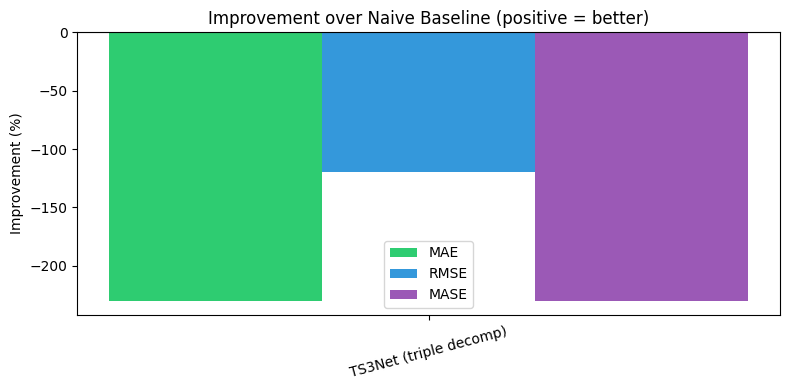

In [11]:
naive_mae = results_df[results_df['Model'] == 'Naive Baseline']['MAE'].values[0]
naive_rmse = results_df[results_df['Model'] == 'Naive Baseline']['RMSE'].values[0]
naive_mase = results_df[results_df['Model'] == 'Naive Baseline']['MASE'].values[0]
improvement = results_df[results_df['Model'] != 'Naive Baseline'].copy()
improvement['MAE_imp_%'] = (1 - improvement['MAE'] / naive_mae) * 100
improvement['RMSE_imp_%'] = (1 - improvement['RMSE'] / naive_rmse) * 100
improvement['MASE_imp_%'] = (1 - improvement['MASE'] / naive_mase) * 100
print('Improvement over Naive Baseline (%):')
display(improvement[['Model', 'MAE_imp_%', 'RMSE_imp_%', 'MASE_imp_%']].round(2))
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(improvement))
w = 0.25
ax.bar(x - w, improvement['MAE_imp_%'], w, label='MAE', color='#2ecc71')
ax.bar(x, improvement['RMSE_imp_%'], w, label='RMSE', color='#3498db')
ax.bar(x + w, improvement['MASE_imp_%'], w, label='MASE', color='#9b59b6')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(improvement['Model'], rotation=15)
ax.set_ylabel('Improvement (%)')
ax.legend()
ax.set_title('Improvement over Naive Baseline (positive = better)')
plt.tight_layout()
plt.show()

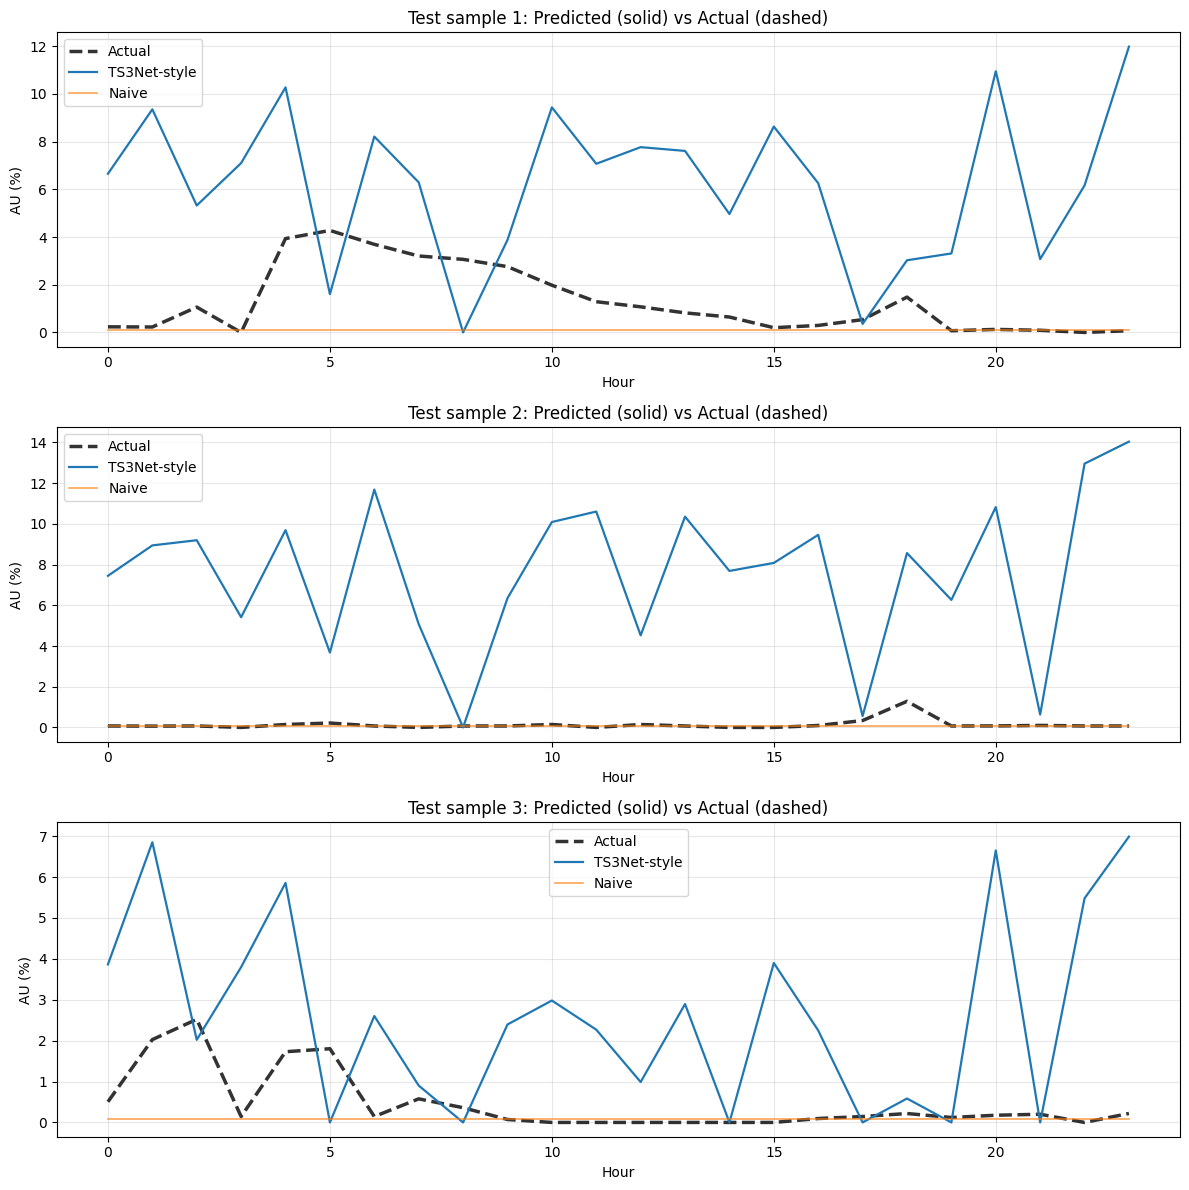

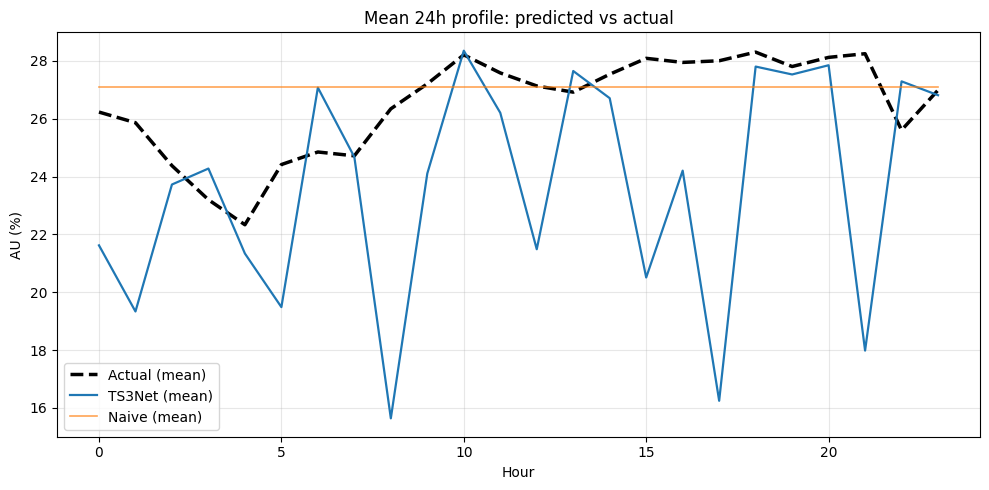

In [12]:
hours = np.arange(FORECAST_HORIZON)
n_show = min(3, len(y_test))
fig, axes = plt.subplots(n_show, 1, figsize=(12, 4*n_show))
if n_show == 1:
    axes = [axes]
for i in range(n_show):
    ax = axes[i]
    ax.plot(hours, y_test[i], 'k--', linewidth=2.5, label='Actual', alpha=0.8)
    ax.plot(hours, y_pred_ts3net[i], '-', linewidth=1.6, label='TS3Net-style')
    ax.plot(hours, y_pred_naive[i], '-', linewidth=1.2, label='Naive', alpha=0.7)
    ax.set_title(f'Test sample {i+1}: Predicted (solid) vs Actual (dashed)')
    ax.set_xlabel('Hour')
    ax.set_ylabel('AU (%)')
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hours, y_test.mean(axis=0), 'k--', linewidth=2.5, label='Actual (mean)')
ax.plot(hours, y_pred_ts3net.mean(axis=0), '-', linewidth=1.6, label='TS3Net (mean)')
ax.plot(hours, y_pred_naive.mean(axis=0), '-', linewidth=1.2, label='Naive (mean)', alpha=0.7)
ax.set_title('Mean 24h profile: predicted vs actual')
ax.set_xlabel('Hour')
ax.set_ylabel('AU (%)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

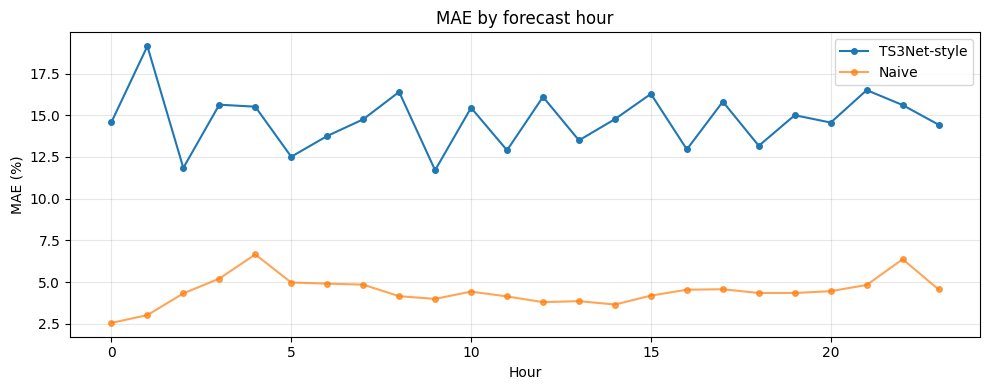

In [13]:
mae_per_hour_ts3 = np.abs(y_test - y_pred_ts3net).mean(axis=0)
mae_per_hour_naive = np.abs(y_test - y_pred_naive).mean(axis=0)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hours, mae_per_hour_ts3, '-o', label='TS3Net-style', markersize=4)
ax.plot(hours, mae_per_hour_naive, '-o', label='Naive', markersize=4, alpha=0.7)
ax.set_title('MAE by forecast hour')
ax.set_xlabel('Hour')
ax.set_ylabel('MAE (%)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

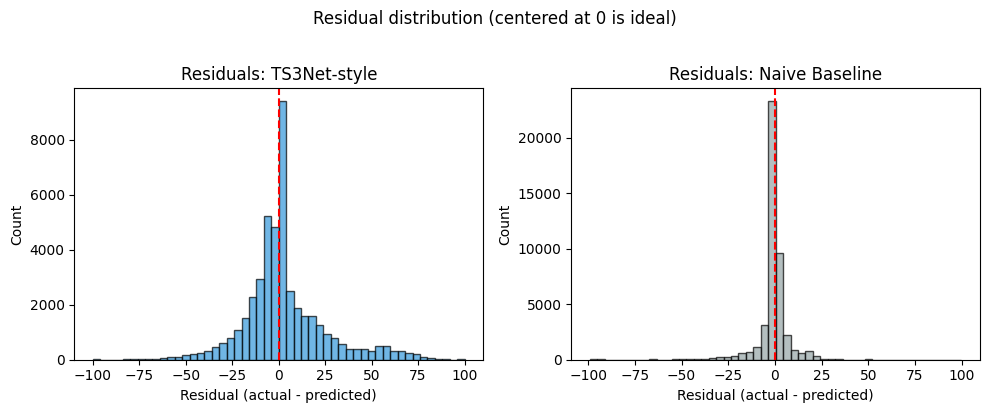

Residual mean (bias): TS3Net = 2.8384, Naive = -0.5887
Residual std:         TS3Net = 22.2790, Naive = 10.2179


In [14]:
residuals_best = (y_test - y_pred_ts3net).flatten()
residuals_naive = (y_test - y_pred_naive).flatten()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(residuals_best, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_xlabel('Residual (actual - predicted)')
axes[0].set_ylabel('Count')
axes[0].set_title('Residuals: TS3Net-style')
axes[1].hist(residuals_naive, bins=50, color='#95a5a6', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (actual - predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residuals: Naive Baseline')
plt.suptitle('Residual distribution (centered at 0 is ideal)', y=1.02)
plt.tight_layout()
plt.show()
print(f'Residual mean (bias): TS3Net = {residuals_best.mean():.4f}, Naive = {residuals_naive.mean():.4f}')
print(f'Residual std:         TS3Net = {residuals_best.std():.4f}, Naive = {residuals_naive.std():.4f}')

### Key insights

- **TS3Net (paper):** Triple decomposition (trend, regular, fluctuant) separates baseline drift, stable periodicity, and dynamic spectrum; TF-blocks learn from 2D temporal-frequency representation; summing the three predictions gives the final forecast.
- **Improvement over naive:** Positive % means the model beats the last-value baseline.
- **Mean profile / per-hour MAE / residuals:** Same interpretation as notebooks 10–16.

In [15]:
best_row = results_df[results_df['Model'] == 'TS3Net (triple decomp)'].iloc[0]
imp_mae = (1 - best_row['MAE'] / naive_mae) * 100
print(f"Best model: TS3Net (triple decomp) (MAE={best_row['MAE']:.4f}, RMSE={best_row['RMSE']:.4f}, MASE={best_row['MASE']:.4f}).")
print(f"Improvement over Naive: MAE {imp_mae:+.1f}%.")

Best model: TS3Net (triple decomp) (MAE=14.7054, RMSE=22.4590, MASE=7.0535).
Improvement over Naive: MAE -230.5%.
